# 📊 Global Results Visualization

This notebook is part of the article **“DCMC-Fusion: Data-Centric and Model-Centric Ensemble Learning for Audio Deepfake Detection”**, by **Dora Ballesteros and Carlos Guerra**.

The notebook reads the global metrics obtained for the DCMC-Fusion experiments with $K=1,\ldots,5$ and the **One-Hard Voting** baseline, and generates the figures used to compare their performance.

- For $K=1,\ldots,4$, the results are represented using **box plots**, since several architecture combinations are evaluated.

- For $K=5$, only one architecture combination exists; therefore, the corresponding results are represented as **individual points**.

- The four **DCMC-Fusion classifiers** are presented together within each value of $K$.

- **One-Hard Voting** is visually separated from the DCMC-Fusion classifiers to emphasize its role as the comparison baseline.


# **1. Libraries and paths**


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Repository structure:
# DCMC_Fusion/
# ├── notebooks/   <- this notebook
# └── results/     <- global metric CSV files

from pathlib import Path

# CSV files uploaded directly to Google Colab
RESULTS_DIR = Path("/content")

# Folder where the generated figures will be saved
FIGURES_DIR = Path("/content/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

K_FILES = {
    1: RESULTS_DIR / "global_metrics_k1.csv",
    2: RESULTS_DIR / "global_metrics_k2.csv",
    3: RESULTS_DIR / "global_metrics_k3.csv",
    4: RESULTS_DIR / "global_metrics_k4.csv",
    5: RESULTS_DIR / "global_metrics_k5.csv",
}

ONE_HARD_FILE = RESULTS_DIR / "global_metrics_one_hard.csv"


FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

K_FILES = {
    1: RESULTS_DIR / "global_metrics_k1.csv",
    2: RESULTS_DIR / "global_metrics_k2.csv",
    3: RESULTS_DIR / "global_metrics_k3.csv",
    4: RESULTS_DIR / "global_metrics_k4.csv",
    5: RESULTS_DIR / "global_metrics_k5.csv",
}

ONE_HARD_FILE = RESULTS_DIR / "global_metrics_one_hard.csv"


# **2. Load and validate the experimental results**


In [ ]:
frames = []

for k, path in K_FILES.items():
    df = pd.read_csv(path)
    df["K"] = k
    frames.append(df)

dcmc = pd.concat(frames, ignore_index=True)
one_hard = pd.read_csv(ONE_HARD_FILE)

required_columns = {
    "K", "architectures", "classifier",
    "accuracy", "precision_macro", "recall_macro", "f1_macro"
}

for name, df in [("DCMC-Fusion", dcmc), ("One-Hard", one_hard)]:
    missing = required_columns.difference(df.columns)
    if missing:
        raise ValueError(f"{name}: missing columns: {sorted(missing)}")

expected_dcmc = {1: 20, 2: 40, 3: 40, 4: 20, 5: 4}
expected_one_hard = {1: 5, 2: 10, 3: 10, 4: 5, 5: 1}

assert dcmc.groupby("K").size().to_dict() == expected_dcmc
assert one_hard.groupby("K").size().to_dict() == expected_one_hard

print("DCMC-Fusion configurations:", len(dcmc))
print("One-Hard configurations:", len(one_hard))
print("Total evaluated configurations:", len(dcmc) + len(one_hard))


DCMC-Fusion configurations: 124
One-Hard configurations: 31
Total evaluated configurations: 155


# **3. Accuracy and macro-recall verification**

The test partition used in the experiments is perfectly balanced between natural and synthetic audio, with the same number of samples in each class:

$$
N_0=N_1=N
$$

Under this condition, **Accuracy and macro-averaged Recall are mathematically equivalent**. For binary classification:

$$
\mathrm{Recall}_{macro}
=
\frac{1}{2}
\left(
\frac{TN}{N_0}
+
\frac{TP}{N_1}
\right)
$$

Since $N_0=N_1=N$:

$$
\mathrm{Recall}_{macro}
=
\frac{TN+TP}{2N}
$$

and, because the total number of test samples is $N_0+N_1=2N$:

$$
\mathrm{Accuracy}
=
\frac{TN+TP}{2N}
=
\mathrm{Recall}_{macro}
$$

The following cell verifies this equality directly from the reported experimental results.

Therefore, since both metrics contain the same information in this experimental setting, the notebook generates figures for:

- **Accuracy**
- **Precision-macro**
- **F1-macro**

The **Recall-macro** figure is omitted to avoid presenting redundant information.


In [ ]:
dcmc_equal = np.allclose(dcmc["accuracy"], dcmc["recall_macro"])
oh_equal = np.allclose(one_hard["accuracy"], one_hard["recall_macro"])

print("DCMC-Fusion: Accuracy = Recall-macro:", dcmc_equal)
print("One-Hard:    Accuracy = Recall-macro:", oh_equal)

if dcmc_equal and oh_equal:
    print(
        "\nAccuracy and macro-recall are identical for all configurations. "
        "The Recall-macro figure is omitted to avoid a redundant visualization."
    )
else:
    print("\nWarning: Accuracy and Recall-macro are not identical in all configurations.")


DCMC-Fusion: Accuracy = Recall-macro: True
One-Hard:    Accuracy = Recall-macro: True

Accuracy and macro-recall are identical for all configurations. The Recall-macro figure is omitted to avoid a redundant visualization.


# **4. Visualization function**

Each figure contains five panels, one for each value of \(K\). Within every panel, the four DCMC-Fusion classifiers are displayed on the left and **One-Hard Voting** is separated on the right.

The same visual configuration is used for all metrics to facilitate comparison across figures.


In [ ]:
CLASSIFIERS = [
    "Logistic Regression",
    "SVM",
    "Random Forest",
    "XGBoost",
]

SHORT_NAMES = {
    "Logistic Regression": "LR",
    "SVM": "SVM",
    "Random Forest": "RF",
    "XGBoost": "XGBoost",
}

# Consistent palette for all figures
COLORS = {
    "Logistic Regression": "#4C78A8",
    "SVM": "#F28E2B",
    "Random Forest": "#59A14F",
    "XGBoost": "#E15759",
    "One-Hard": "#A7A7A7",
}

HEADER_COLORS = ["#B8AEF4", "#F7BF91", "#9DDFAC", "#F3A0B3", "#F6D36F"]


def plot_metric(metric, ylabel, filename, ylim=(0.4, 0.9)):
    fig, axes = plt.subplots(
        1, 5, figsize=(16, 7), sharey=True,
        gridspec_kw={"wspace": 0.05}
    )

    for idx, (ax, k) in enumerate(zip(axes, range(1, 6))):
        ax.set_facecolor("white")

        # DCMC-Fusion: four classifiers on the left
        positions = [1.0, 1.8, 2.6, 3.4]

        for pos, clf in zip(positions, CLASSIFIERS):
            values = dcmc.loc[
                (dcmc["K"] == k) & (dcmc["classifier"] == clf), metric
            ].dropna().to_numpy()

            if k < 5:
                bp = ax.boxplot(
                    [values],
                    positions=[pos],
                    widths=0.48,
                    patch_artist=True,
                    showfliers=True,
                    medianprops={"color": "black", "linewidth": 1.3},
                    boxprops={"edgecolor": COLORS[clf], "linewidth": 1.4},
                    whiskerprops={"color": COLORS[clf], "linewidth": 1.2},
                    capprops={"color": COLORS[clf], "linewidth": 1.2},
                    flierprops={
                        "marker": "o",
                        "markersize": 3.5,
                        "markerfacecolor": "black",
                        "markeredgecolor": "black",
                    },
                )
                bp["boxes"][0].set_facecolor(COLORS[clf])
                bp["boxes"][0].set_alpha(0.60)
            else:
                ax.scatter(
                    pos, values[0],
                    s=55, color=COLORS[clf],
                    edgecolor="white", linewidth=0.6, zorder=4
                )

        # One-Hard Voting: separated on the right
        oh_values = one_hard.loc[one_hard["K"] == k, metric].dropna().to_numpy()
        oh_pos = 5.15

        if k < 5:
            bp = ax.boxplot(
                [oh_values],
                positions=[oh_pos],
                widths=0.52,
                patch_artist=True,
                showfliers=True,
                medianprops={"color": "black", "linewidth": 1.3},
                boxprops={"edgecolor": "black", "linewidth": 1.3},
                whiskerprops={"color": "black", "linewidth": 1.1},
                capprops={"color": "black", "linewidth": 1.1},
                flierprops={
                    "marker": "o",
                    "markersize": 3.5,
                    "markerfacecolor": "black",
                    "markeredgecolor": "black",
                },
            )
            bp["boxes"][0].set_facecolor(COLORS["One-Hard"])
            bp["boxes"][0].set_alpha(0.55)
        else:
            ax.scatter(
                oh_pos, oh_values[0],
                s=55, color=COLORS["One-Hard"],
                edgecolor="white", linewidth=0.6, zorder=4
            )

        # Separation between DCMC-Fusion and baseline
        ax.axvline(4.35, color="#9A9A9A", linestyle="--", linewidth=1.0)

        # Panel header
        ax.text(
            0.5, 1.045, rf"$K={k}$",
            transform=ax.transAxes,
            ha="center", va="center",
            fontsize=18, fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.55",
                facecolor=HEADER_COLORS[idx],
                edgecolor=HEADER_COLORS[idx],
                alpha=0.95
            )
        )

        # Group labels
        ax.text(
            0.34, 0.965, "DCMC-Fusion",
            transform=ax.transAxes,
            ha="center", va="top",
            fontsize=10.5, fontweight="bold"
        )
        ax.text(
            0.86, 0.965, "One-Hard\nVoting",
            transform=ax.transAxes,
            ha="center", va="top",
            fontsize=10, fontweight="bold"
        )

        ax.set_xlim(0.55, 5.65)
        ax.set_ylim(*ylim)
        ax.set_xticks([])
        ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.25)

        for spine in ax.spines.values():
            spine.set_linewidth(0.8)

    axes[0].set_ylabel(ylabel, fontsize=15)

    legend_handles = [
        Patch(
            facecolor=COLORS[clf],
            edgecolor=COLORS[clf],
            alpha=0.60,
            label=SHORT_NAMES[clf]
        )
        for clf in CLASSIFIERS
    ]
    legend_handles.append(
        Patch(
            facecolor=COLORS["One-Hard"],
            edgecolor="black",
            alpha=0.55,
            label="One-Hard Voting (baseline)"
        )
    )

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=5,
        frameon=True,
        fontsize=11
    )

    fig.subplots_adjust(left=0.07, right=0.99, top=0.86, bottom=0.15)

    output = FIGURES_DIR / filename
    fig.savefig(output, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

    print(f"Saved: {output}")


# **5. Accuracy**


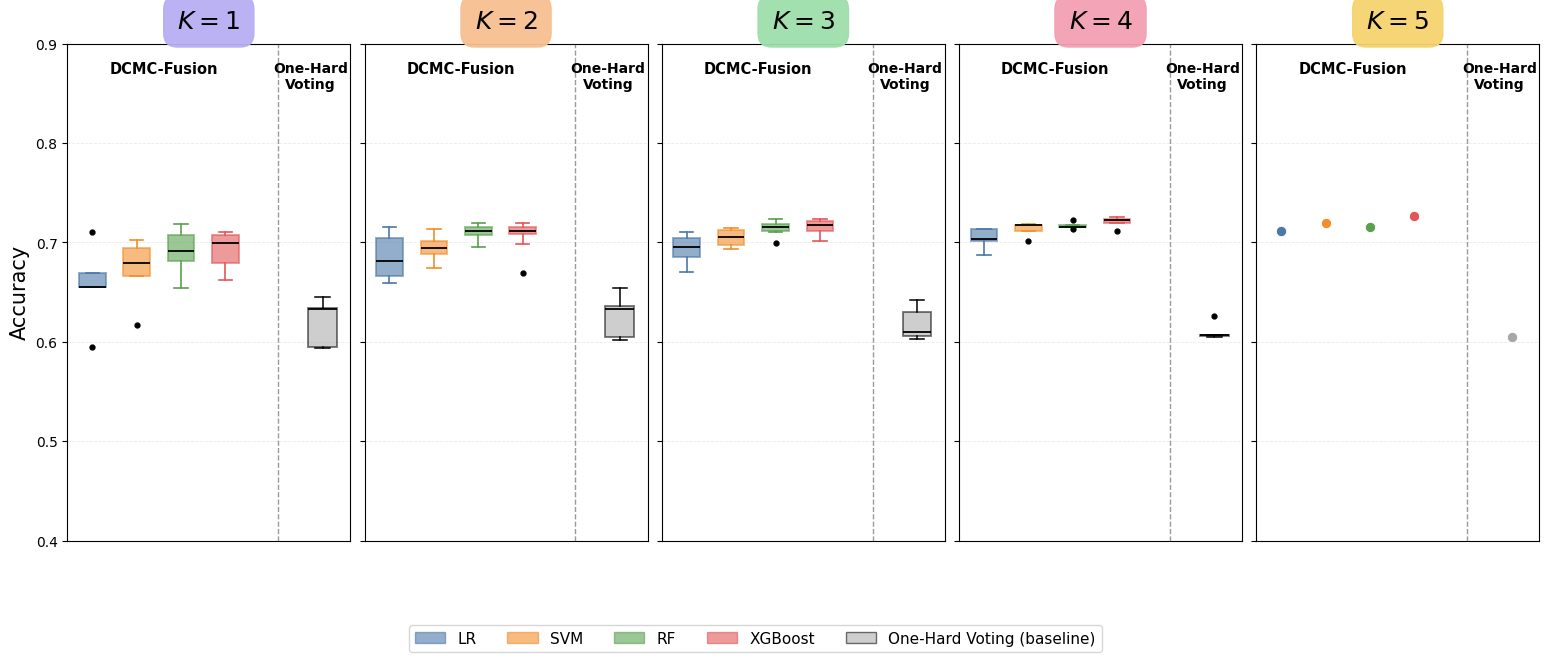

Saved: /content/figures/accuracy_DCMC_vs_OneHard.png


In [ ]:
plot_metric(
    metric="accuracy",
    ylabel="Accuracy",
    filename="accuracy_DCMC_vs_OneHard.png"
)


# **6. Precision-macro**


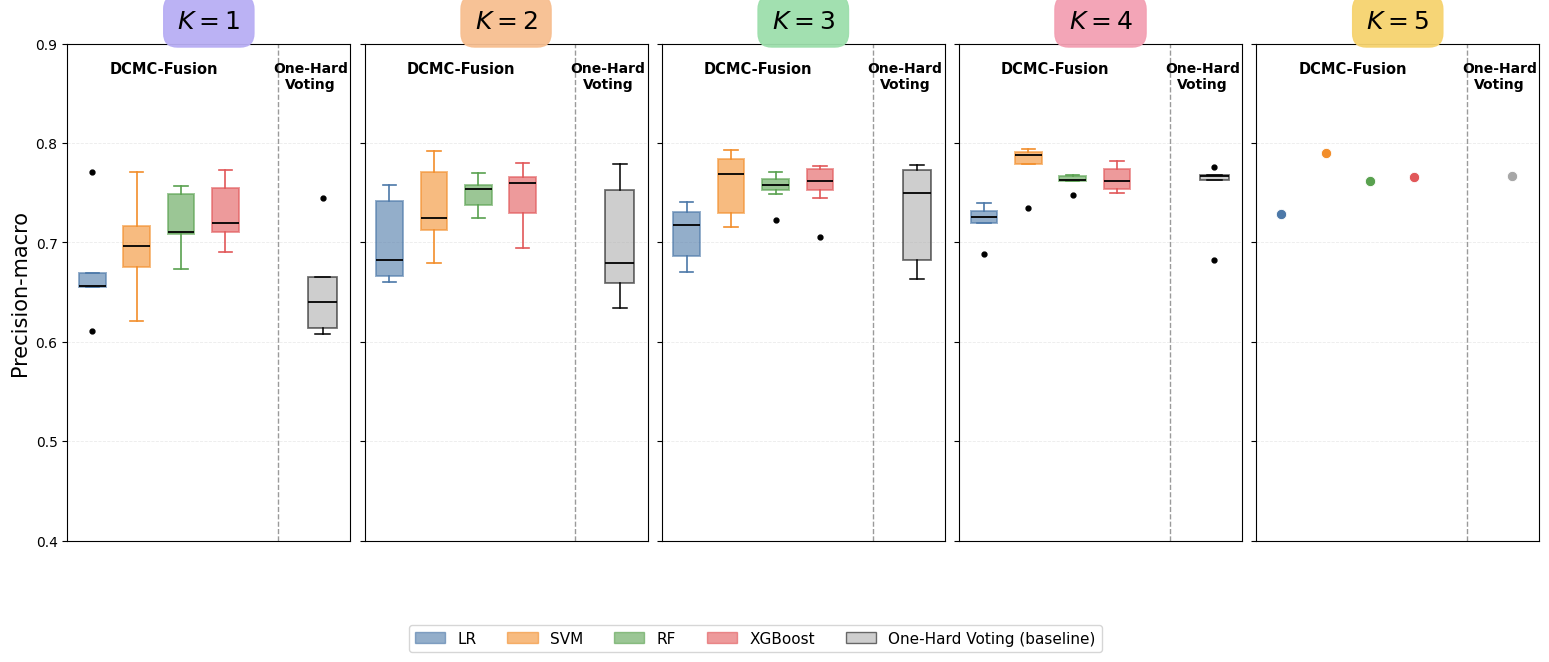

Saved: /content/figures/precision_macro_DCMC_vs_OneHard.png


In [ ]:
plot_metric(
    metric="precision_macro",
    ylabel="Precision-macro",
    filename="precision_macro_DCMC_vs_OneHard.png"
)


# **7. F1-macro**


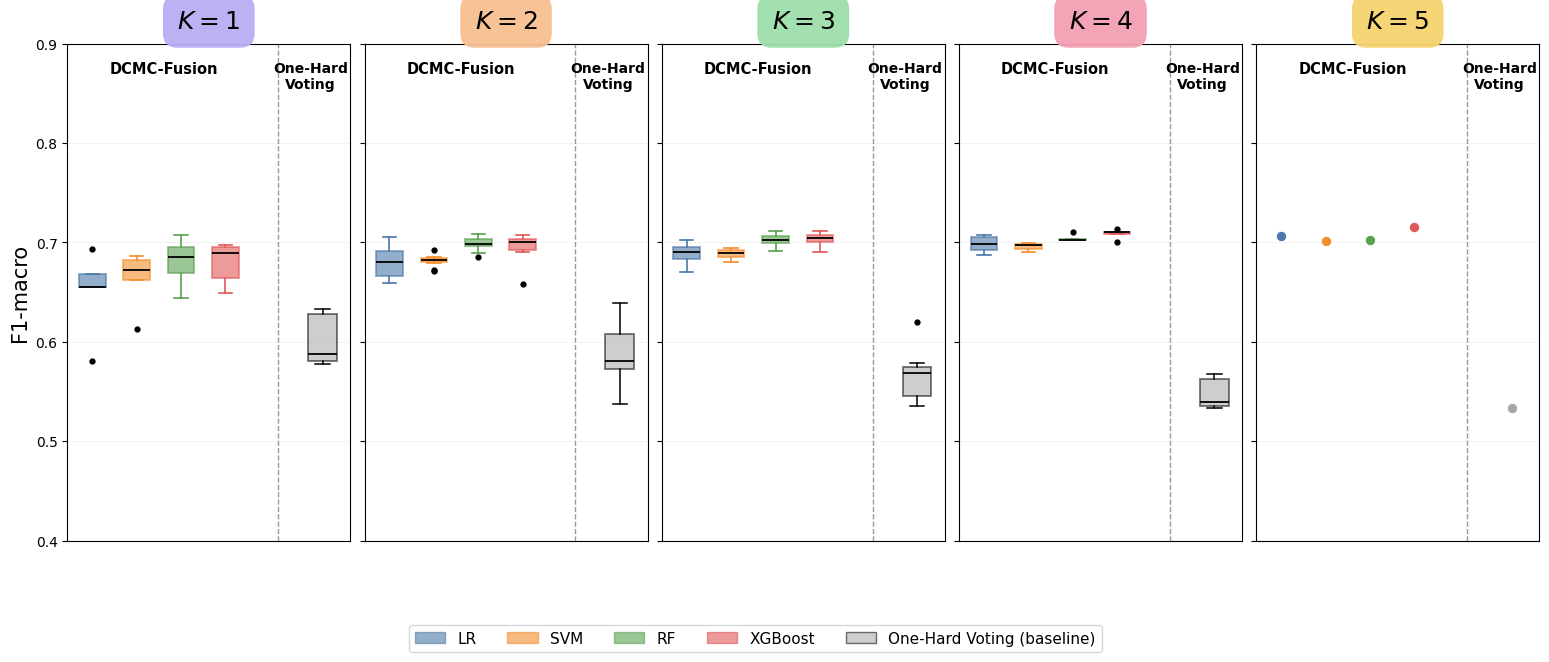

Saved: /content/figures/f1_macro_DCMC_vs_OneHard.png


In [ ]:
plot_metric(
    metric="f1_macro",
    ylabel="F1-macro",
    filename="f1_macro_DCMC_vs_OneHard.png"
)


# **8. Generated figures**

The three figures are saved in:

```text
results/figures/
├── accuracy_DCMC_vs_OneHard.png
├── precision_macro_DCMC_vs_OneHard.png
└── f1_macro_DCMC_vs_OneHard.png
```

These visualizations summarize the effect of the number and composition of architectures (\(K\)) and the fusion classifier, while maintaining One-Hard Voting as an independent comparison baseline.
